# Exploring Feature Selection Methods: MRMR, RFE and RENT
### Nested CV with Optuna hyperparameter tuning
### Elasticnet Model


In [1]:
import sys, os
sys.path.insert(0, '../src')
import joblib
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import preprocess
import explore
import model
import model_elasticnet
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path for storing results
MODEL_DIR = os.path.abspath('../models')


In [2]:
# Running through preprocessing steps
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)
# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

# Modeling with T2 immunological data


In [3]:
# Creating Target
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_targets, timepoints=[2])


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.347  std=2.051  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.196  std=32.847  [-100.000, 87.654]

Constructing datasets for modeling:

Modeling dataset ready: T2 features + clinical features
Shape: (130, 95),  Patients: 130


## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning

### Target: pain_reduction_pct

In [6]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_mrmr_results_df, en_feature_freq, en_sel_per_fold = model_elasticnet.elasticnet_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_mrmr_results_df,      os.path.join(MODEL_DIR, 'en_results_df.pkl'))
joblib.dump(en_feature_freq,         os.path.join(MODEL_DIR, 'en_feature_freq.pkl'))
joblib.dump(en_sel_per_fold,         os.path.join(MODEL_DIR, 'en_sel_per_fold.pkl'))



 Nested CV - ElasticNet + MRMR + Optuna — pain_reduction_pct
  n=130, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best MRMR params: {'K': 20, 'n_estimators': 50, 'max_depth': 2, 'min_samples_leaf': 8}  RMSE=1.1503
  20 selected features: ['Basophils_t2', 'CD123lo Bas_t2', 'T8lo_t2', 'Mo1_t2', 'NKT_56+_t2', 'Neu_CD25+_t2', 'BAS_CD25+_t2', 'NK_CD25+_t2', 'Mo_HLADR+_t2', 'Mo3_HLADR+_t2', 'T_HLADR+_t2', 'TC_HLADR+_t2', 'T_CD69+_t2', 'TH_CD69+_t2', 'NK_CD69+_t2', 'TC_PD1+_t2', 'NLR_t2', 'weight_kg', 'height_cm', 'target_volume_side']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  2/50   RMSE=1.0215  {'alpha': 7.633111637900109, 'l1_ratio': 0.8810732229580653}
  MAE=22.607  RMSE=31.515  R²=-0.016

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_sel_per_fold.pkl']

## Plot of Feature Frequency List 
Top 25 Features Selections Shown.

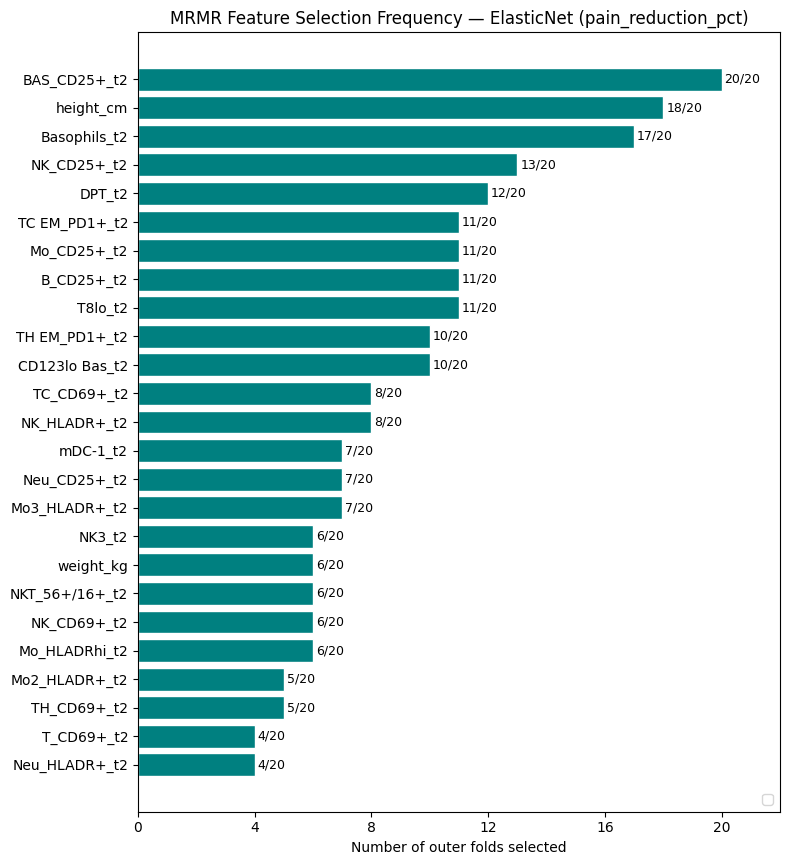

In [7]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq.pkl'))
model.plot_feature_frequency(feature_list, name='ElasticNet (pain_reduction_pct)', top=25)

## Jaccard Score of MRMR Selected Features
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (MRMR Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.275 ± 0.088
  Min  Jaccard : 0.111
  Max  Jaccard : 0.667


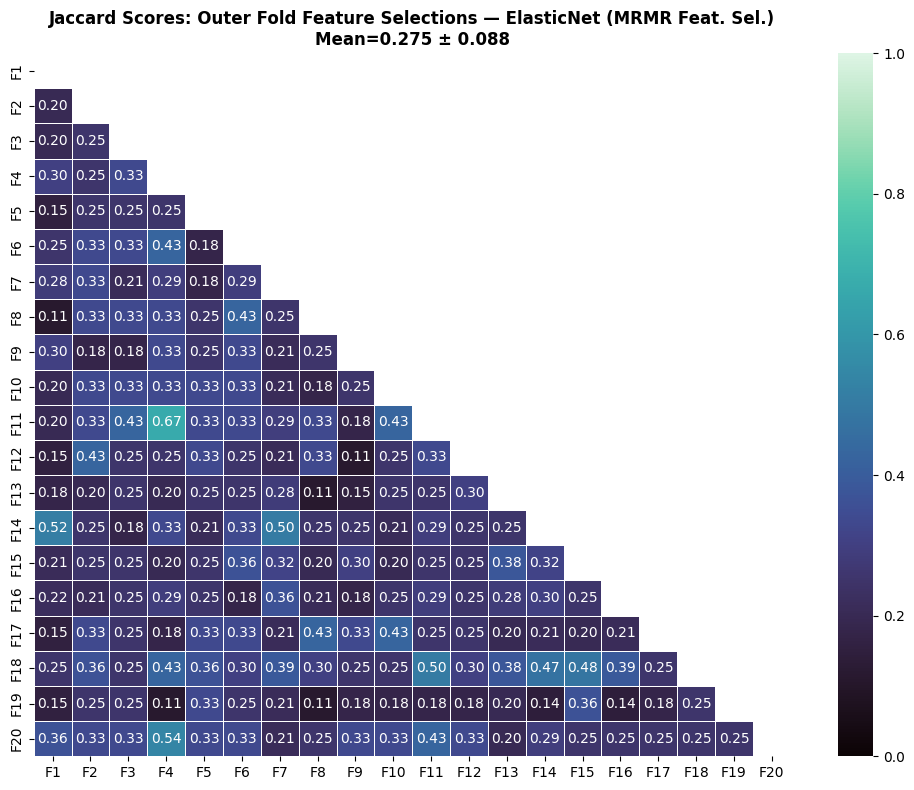

In [8]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'en_sel_per_fold.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='ElasticNet (MRMR Feat. Sel.)')

# ElasticNet + RFE Feature Selection
## Nested CV and Optuna hyperparameter tuning

In [10]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_rfe_results_df, en_rfe_freq, en_rfe_per_fold = model_elasticnet.elasticnet_rfe(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_rfe_results_df,      os.path.join(MODEL_DIR, 'en_rfe_df.pkl'))
joblib.dump(en_rfe_freq,         os.path.join(MODEL_DIR, 'en_rfe_freq.pkl'))
joblib.dump(en_rfe_per_fold,         os.path.join(MODEL_DIR, 'en_rfe_per_fold.pkl'))



 Nested CV - ElasticNet + RFE + Optuna — pain_reduction_pct
  n=130, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials RFE=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RFE params: {'n_features_to_select': 15, 'step': 10}  RMSE=1.2362
  15 selected features: ['Neutrophils_t2', 'TH_t2', 'TC_t2', 'T4:T8 ratio_t2', 'T8hi_t2', 'Mo1_t2', 'NKT_56+_t2', 'T_CD25+_t2', 'TH_CD25+_t2', 'T_CD25hi_t2', 'TH_CD25hi_t2', 'T_HLADR+_t2', 'T_CD69+_t2', 'TH_CD69+_t2', 'NK_CD69+_t2']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  34/50   RMSE=0.9897  {'alpha': 0.004136528421347921, 'l1_ratio': 0.0018814593917515238}
  MAE=29.852  RMSE=42.113  R²=-0.815

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─────────────────────────────────────────────────────────────────
  Best RFE params: {'n_features_to_select': 15,

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_rfe_per_fold.pkl']

## Jaccard Score of REF Selected Features
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (RFE Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.193 ± 0.095
  Min  Jaccard : 0.000
  Max  Jaccard : 0.538


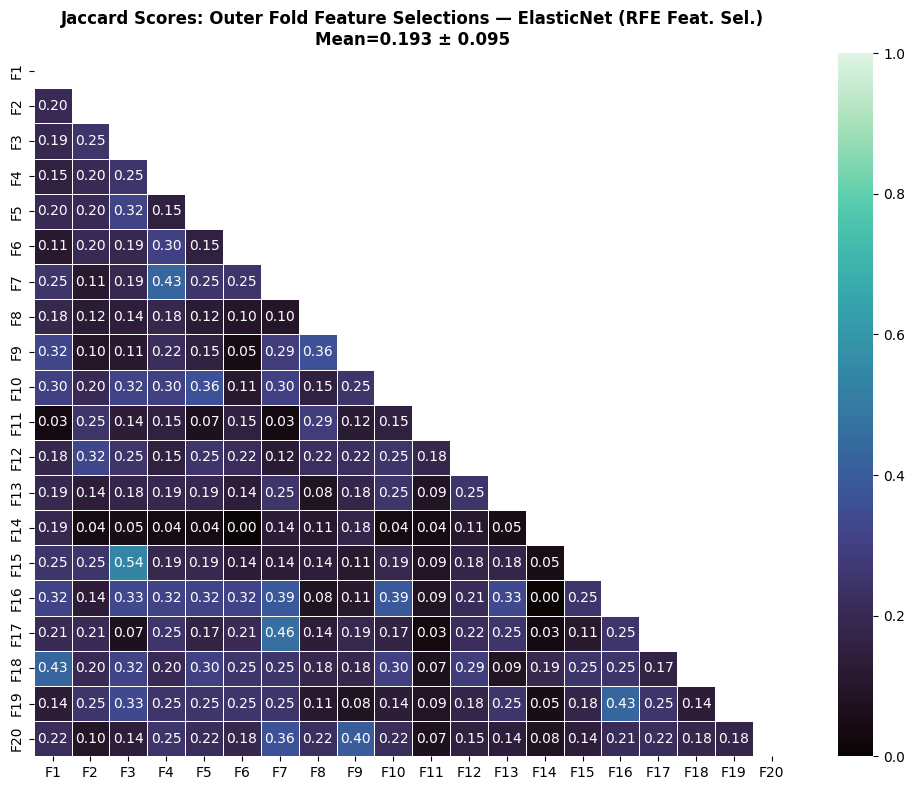

In [7]:
selected_per_fold_rfe = joblib.load(os.path.join(MODEL_DIR, 'en_rfe_per_fold.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold_rfe, name='ElasticNet (RFE Feat. Sel.)')

# Elasticnet + RENT feature Selection
## Nested CV + Optuna hyperparameter tuning

In [4]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_rent_results, en_rent_freq, en_rent_per_fold = model_elasticnet.elasticnet_rent(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_rent_results,      os.path.join(MODEL_DIR, 'en_rent_results.pkl'))
joblib.dump(en_rent_freq,         os.path.join(MODEL_DIR, 'en_rent_freq.pkl'))
joblib.dump(en_rent_per_fold,         os.path.join(MODEL_DIR, 'en_rent_per_fold.pkl'))


 Nested CV - ElasticNet + RENT + Optuna — pain_reduction_pct
  n=130, p=92, τ₃=0.975
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials RENT=20 | K=100

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RENT params: {'C': 6.919260624203806, 'l1_ratio': 0.9516085375906125, 'tau_1': 0.4249235034432588}  RMSE=1.2362
  7 selected features: ['Basophils_t2', 'T4:T8 ratio_t2', 'NKT_t2', 'DPT_t2', 'mDC-1_t2', 'BAS_CD25+_t2', 'TC EM_PD1+_t2']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  21/50   RMSE=0.9770  {'alpha': 0.4510050420623324, 'l1_ratio': 0.001997028681918257}
  MAE=22.920  RMSE=29.856  R²=0.088

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─────────────────────────────────────────────────────────────────
  Best RENT params: {'C': 2.9725171744888725, 'l1_ratio': 0.5632420054270807, 'tau_1': 0.561820

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_rent_per_fold.pkl']

## Jaccard Score of RENT Selected Features
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (RENT Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.230 ± 0.195
  Min  Jaccard : 0.011
  Max  Jaccard : 1.000


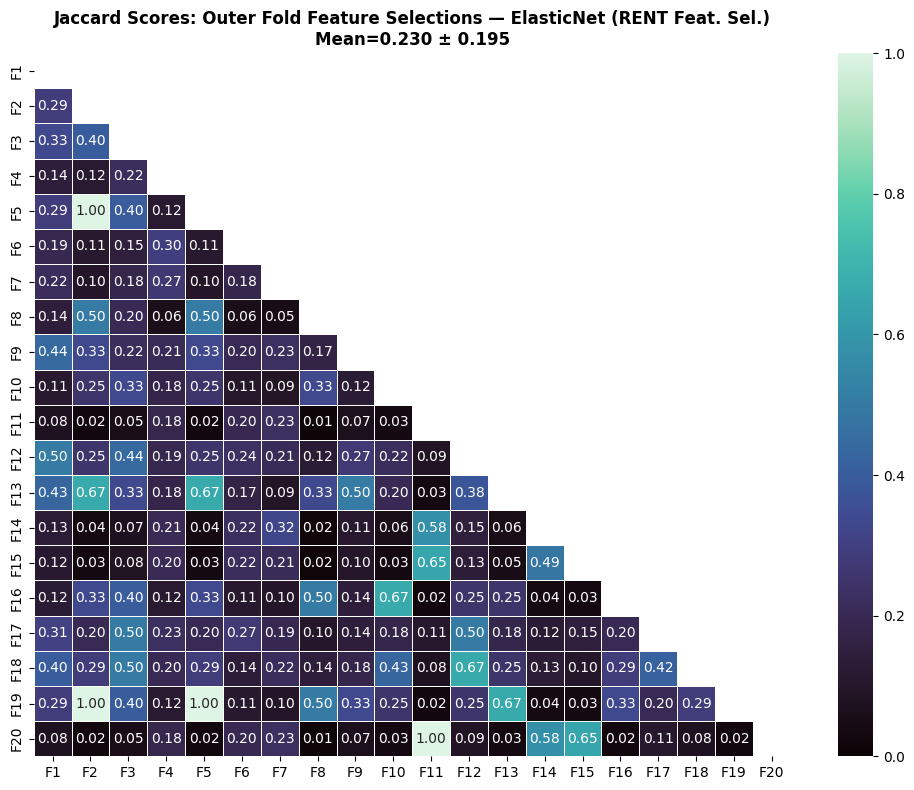

In [9]:
selected_per_fold_rent = joblib.load(os.path.join(MODEL_DIR, 'en_rent_per_fold.pkl'))
jac_matrix_rent = model.jaccard_scores(selected_per_fold_rent, name='ElasticNet (RENT Feat. Sel.)')

## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning
### Target:  pain_under_load_reduction_pct

In [10]:
# Creating Target
print('\nConstructing regression targets from clinical data')
pain_ul_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_under_load',      [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain_ul = model.create_model_datasets(df_im_mod, df_cl_mod, pain_ul_targets, timepoints=[2])


Constructing regression targets from clinical data

  Target distributions:
    pain_under_load_reduction                   mean=0.551  std=0.753  [-1.000, 3.000]
    pain_under_load_reduction_pct               mean=14.125  std=20.231  [-50.000, 75.000]

Constructing datasets for modeling:

Modeling dataset ready: T2 features + clinical features
Shape: (128, 95),  Patients: 128


In [11]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_mrmr_ul_results, en_mrmr_ul_freq, en_mrmr_ul_per_fold = model_elasticnet.elasticnet_mrmr(
        df_pain_ul,
        target_col='pain_under_load_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_mrmr_ul_results,      os.path.join(MODEL_DIR, 'en_mrmr_ul_results.pkl'))
joblib.dump(en_mrmr_ul_freq,         os.path.join(MODEL_DIR, 'en_mrmr_ul_freq.pkl'))
joblib.dump(en_mrmr_ul_per_fold,         os.path.join(MODEL_DIR, 'en_mrmr_ul_per_fold.pkl'))


 Nested CV - ElasticNet + MRMR + Optuna — pain_under_load_reduction_pct
  n=128, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best MRMR params: {'K': 10, 'n_estimators': 200, 'max_depth': 2, 'min_samples_leaf': 5}  RMSE=0.9085
  10 selected features: ['CD123lo Bas_t2', 'mDC-1_t2', 'BAS_CD25+_t2', 'T_CD25+_t2', 'B_CD25+_t2', 'NK_CD25+_t2', 'T_CD69+_t2', 'NK_CD69+_t2', 'TC_PD1+_t2', 'cumulative_dose']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  31/50   RMSE=0.9518  {'alpha': 1.153698497188576, 'l1_ratio': 0.0014296832088599373}
  MAE=15.660  RMSE=20.606  R²=0.100

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─────────────────────────────────────────────────────────────────
  Best MRMR params: {'K': 10, 'n_estimators': 200, 'max_depth': 8

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_mrmr_ul_per_fold.pkl']

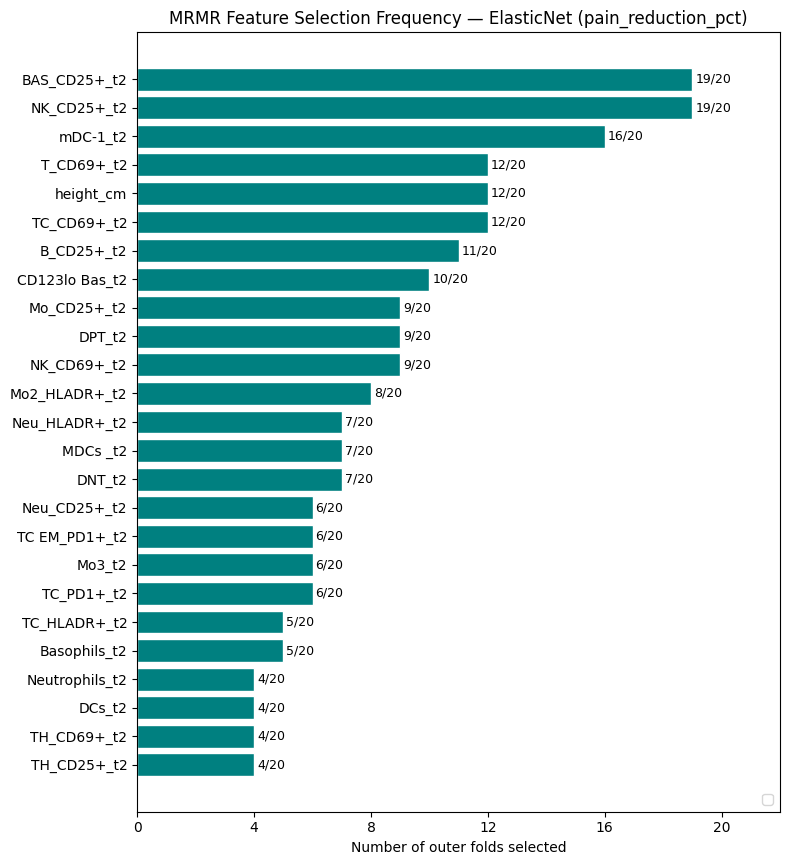

In [18]:
feat_list_ul = joblib.load(os.path.join(MODEL_DIR, 'en_mrmr_ul_freq.pkl'))
model.plot_feature_frequency(feat_list_ul, name='ElasticNet (pain_reduction_pct)', top=25)

## Jaccard Score MRMR Selected Features 
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (MRMR Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.278 ± 0.098
  Min  Jaccard : 0.053
  Max  Jaccard : 0.667


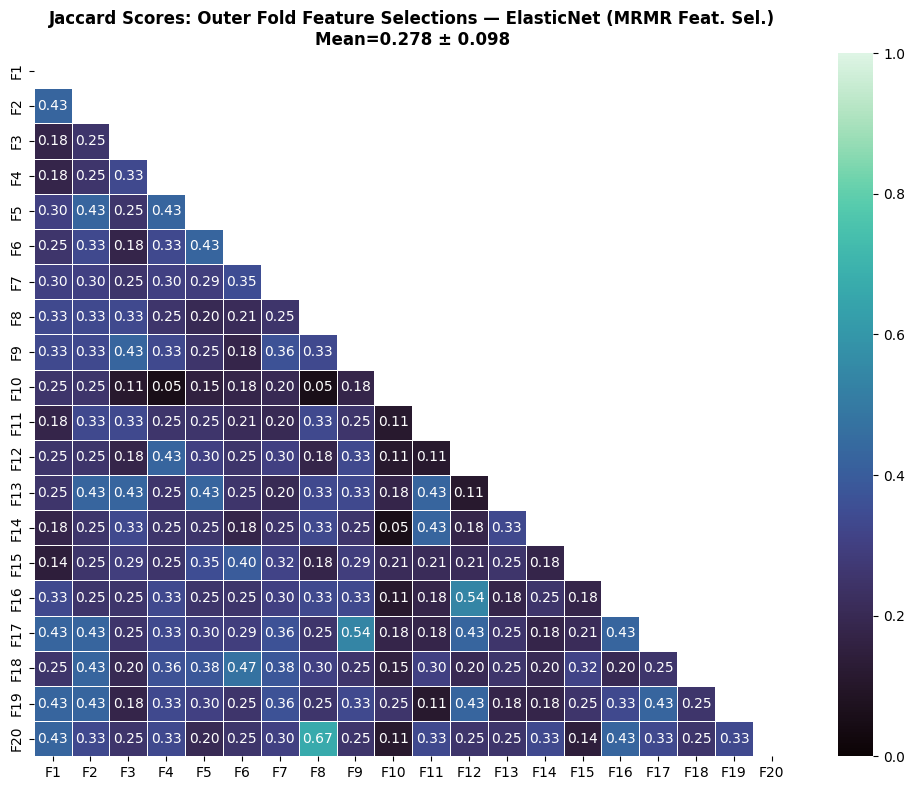

In [12]:
selected_per_fold_mrmr_ul = joblib.load(os.path.join(MODEL_DIR, 'en_mrmr_ul_per_fold.pkl'))
jac_matrix_mrmr_ul = model.jaccard_scores(selected_per_fold_mrmr_ul, name='ElasticNet (MRMR Feat. Sel.)')

## Elasticnet + RFE Feature selection
### Target: pain_under_load_reduction_pct

In [14]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_rfe_ul_results, en_rfe_ul_freq, en_rfe_ul_per_fold = model_elasticnet.elasticnet_rfe(
        df_pain_ul,
        target_col='pain_under_load_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_rfe_ul_freq,         os.path.join(MODEL_DIR, 'en_rfe_ul_freq.pkl'))
joblib.dump(en_rfe_ul_per_fold,         os.path.join(MODEL_DIR, 'en_rfe_ul_per_fold.pkl'))


 Nested CV - ElasticNet + RFE + Optuna — pain_under_load_reduction_pct
  n=128, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials RFE=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RFE params: {'n_features_to_select': 15, 'step': 1}  RMSE=0.9267
  15 selected features: ['Basophils_t2', 'CD123lo Bas_t2', 'T_CD25hi_t2', 'TH_CD25hi_t2', 'B_CD25+_t2', 'Mo_HLADR+_t2', 'Mo_HLADRhi_t2', 'TC_HLADR+_t2', 'TH_HLADR+_t2', 'NK_HLADR+_t2', 'TC_CD69+_t2', 'TH_CD69+_t2', 'NK_CD69+_t2', 'Tc/Treg_t2', 'previous_therapy_1']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  33/50   RMSE=0.9763  {'alpha': 1.051915555744834, 'l1_ratio': 0.0840787722480888}
  MAE=16.460  RMSE=21.428  R²=0.027

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─────────────────────────────────────────────────────────────────
  Best RFE 

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_rfe_ul_per_fold.pkl']

### Jaccard Score of Selected Features


  Jaccard Scores — ElasticNet (RFE Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.196 ± 0.092
  Min  Jaccard : 0.000
  Max  Jaccard : 0.579


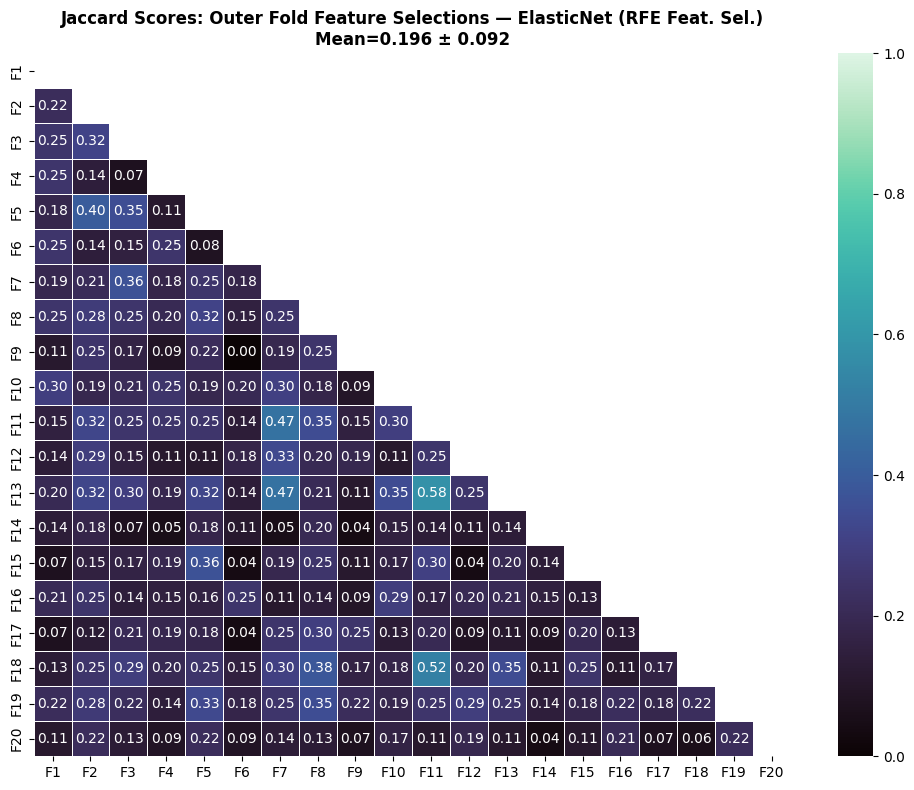

In [15]:
selected_per_fold_rfe_ul = joblib.load(os.path.join(MODEL_DIR, 'en_rfe_ul_per_fold.pkl'))
jac_matrix_rfe_ul = model.jaccard_scores(selected_per_fold_rfe_ul, name='ElasticNet (RFE Feat. Sel.)')

## Elasticnet + RENT feature selection
### Target: pain_under_load_reduction_pct

In [16]:
importlib.reload(model_elasticnet)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

en_rent_ul_results, en_rent_ul_freq, en_rent_ul_per_fold = model_elasticnet.elasticnet_rent(
        df_pain_ul,
        target_col='pain_under_load_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save results, feature frequency list and features selected in each outer fold:
joblib.dump(en_rent_ul_freq,         os.path.join(MODEL_DIR, 'en_rent_ul_freq.pkl'))
joblib.dump(en_rent_ul_per_fold,         os.path.join(MODEL_DIR, 'en_rent_ul_per_fold.pkl'))


 Nested CV - ElasticNet + RENT + Optuna — pain_under_load_reduction_pct
  n=128, p=92, τ₃=0.975
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials RENT=20 | K=100

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
  Best RENT params: {'C': 0.8353055143971051, 'l1_ratio': 0.2183963561433105, 'tau_1': 0.15628003539488133}  RMSE=0.9267
  6 selected features: ['MDCs _t2', 'B_CD25+_t2', 'NK_CD25+_t2', 'NK_CD69+_t2', 'TC_PD1+_t2', 'previous_therapy_6']
     Running 20 Inner Folds, 50 Optuna Trials...
     Best Trial:  44/50   RMSE=0.9444  {'alpha': 0.6759714135041465, 'l1_ratio': 0.03861301566695932}
  MAE=16.048  RMSE=21.567  R²=0.014

─────────────────────────────────────────────────────────────────
  Outer fold 2/20
─────────────────────────────────────────────────────────────────
  Best RENT params: {'C': 2.2318497067699172, 'l1_ratio': 0.3973350906498404, 'tau_1': 0.7

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\en_rent_ul_per_fold.pkl']

### Jaccard Score of Selected Features


  Jaccard Scores — ElasticNet (RENT Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.243 ± 0.167
  Min  Jaccard : 0.022
  Max  Jaccard : 1.000


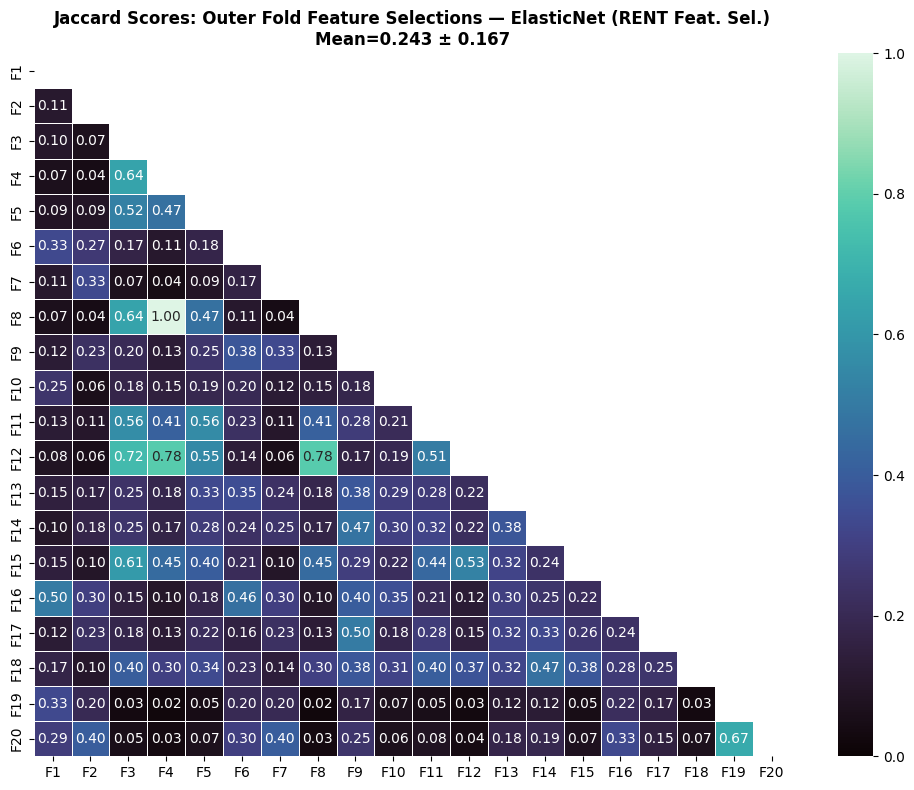

In [17]:
selected_per_fold_rent_ul = joblib.load(os.path.join(MODEL_DIR, 'en_rent_ul_per_fold.pkl'))
jac_matrix_rent_ul = model.jaccard_scores(selected_per_fold_rent_ul, name='ElasticNet (RENT Feat. Sel.)')